# Marginals and Conditionals of a Multivariate Normal: The 5D Case

## Real-World Scenario: Monoclonal Antibody Bioprocessing

**From PML Chapter 3.2.3**

Building on the 2D example, we now consider a **5-dimensional** bioprocessing model where monoclonal antibody (mAb) titer in CHO cell culture depends on multiple correlated process parameters:

| Variable | Description | Units |
|----------|-------------|-------|
| $y_1$ | Culture temperature | °C |
| $y_2$ | Medium pH | pH units |
| $y_3$ | Glucose concentration | g/L |
| $y_4$ | Viable cell density | $10^6$ cells/mL |
| $y_5$ | **Antibody titer** | g/L |

This notebook demonstrates how the **same formulas** from PML 3.2.3 work for higher-dimensional Gaussians, where:
- Variables can be **vectors** (not just scalars)
- Covariance blocks become **matrices** (not just numbers)
- We need **matrix inversion** (not just division)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import multivariate_normal
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Key Formulas from PML 3.2.3 (General Case)

For a jointly Gaussian vector $\mathbf{y} = (\mathbf{y}_1, \mathbf{y}_2)$ where $\mathbf{y}_1 \in \mathbb{R}^{d_1}$ and $\mathbf{y}_2 \in \mathbb{R}^{d_2}$:

$$\boldsymbol{\mu} = \begin{pmatrix} \boldsymbol{\mu}_1 \\ \boldsymbol{\mu}_2 \end{pmatrix}, \quad
\boldsymbol{\Sigma} = \begin{pmatrix} \boldsymbol{\Sigma}_{11} & \boldsymbol{\Sigma}_{12} \\ \boldsymbol{\Sigma}_{21} & \boldsymbol{\Sigma}_{22} \end{pmatrix}$$

where:
- $\boldsymbol{\Sigma}_{11}$ is $d_1 \times d_1$
- $\boldsymbol{\Sigma}_{12}$ is $d_1 \times d_2$
- $\boldsymbol{\Sigma}_{21}$ is $d_2 \times d_1$ (and equals $\boldsymbol{\Sigma}_{12}^T$)
- $\boldsymbol{\Sigma}_{22}$ is $d_2 \times d_2$

### Marginals (Eq. 3.27)
$$p(\mathbf{y}_1) = \mathcal{N}(\mathbf{y}_1 | \boldsymbol{\mu}_1, \boldsymbol{\Sigma}_{11})$$

### Conditionals (Eq. 3.28)
$$p(\mathbf{y}_1 | \mathbf{y}_2) = \mathcal{N}(\mathbf{y}_1 | \boldsymbol{\mu}_{1|2}, \boldsymbol{\Sigma}_{1|2})$$

where:
$$\boldsymbol{\mu}_{1|2} = \boldsymbol{\mu}_1 + \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} (\mathbf{y}_2 - \boldsymbol{\mu}_2)$$
$$\boldsymbol{\Sigma}_{1|2} = \boldsymbol{\Sigma}_{11} - \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} \boldsymbol{\Sigma}_{21}$$

**Key difference from 2D:** Now $\boldsymbol{\Sigma}_{22}^{-1}$ is a **matrix inverse**, not just $1/\sigma^2$!

## Step 1: Define the 5D Joint Distribution

We need to specify:
1. A **5-dimensional mean vector** $\boldsymbol{\mu}$
2. A **5×5 covariance matrix** $\boldsymbol{\Sigma}$

The covariance matrix must be **symmetric positive definite**. We'll build it from correlations and standard deviations.

Our variables model a **fed-batch CHO cell culture** for mAb production, where process parameters are correlated through the underlying cell biology.

In [17]:
# Variable indices for clarity
TEMP = 0      # Culture temperature (°C)
PH = 1        # Medium pH
GLUC = 2      # Glucose concentration (g/L)
VCD = 3       # Viable cell density (10^6 cells/mL)
TITER = 4     # Antibody titer (g/L)

variable_names = ['Temp', 'pH', 'Glucose', 'VCD', 'Titer']
variable_units = ['(°C)', '(pH)', '(g/L)', '(10⁶/mL)', '(g/L)']

# Mean values (typical fed-batch CHO culture at harvest)
# Average: 36.5°C, pH 7.0, 4.0 g/L glucose, 15 × 10^6 cells/mL, 3.5 g/L titer
mu = np.array([36.5,   # temperature in °C
               7.0,    # pH
               4.0,    # glucose in g/L
               15.0,   # VCD in 10^6 cells/mL
               3.5])   # titer in g/L

# Standard deviations
sigmas = np.array([1.5,    # temp: std of 1.5°C (range ~33-40°C)
                   0.15,   # pH: std of 0.15 (range ~6.7-7.3)
                   1.5,    # glucose: std of 1.5 g/L
                   5.0,    # VCD: std of 5 × 10^6 cells/mL
                   1.2])   # titer: std of 1.2 g/L

print("Mean vector μ:")
for i, (name, val, unit) in enumerate(zip(variable_names, mu, variable_units)):
    print(f"  {name}: {val} {unit}")

print("\nStandard deviations σ:")
for i, (name, val, unit) in enumerate(zip(variable_names, sigmas, variable_units)):
    print(f"  {name}: {val} {unit}")

Mean vector μ:
  Temp: 36.5 (°C)
  pH: 7.0 (pH)
  Glucose: 4.0 (g/L)
  VCD: 15.0 (10⁶/mL)
  Titer: 3.5 (g/L)

Standard deviations σ:
  Temp: 1.5 (°C)
  pH: 0.15 (pH)
  Glucose: 1.5 (g/L)
  VCD: 5.0 (10⁶/mL)
  Titer: 1.2 (g/L)


In [18]:
# Correlation matrix (must be symmetric with 1s on diagonal)
# Think about realistic correlations in CHO cell culture:
#   - Temp ↔ pH: slight positive (both tightly controlled, mild protocol correlation)
#   - Temp ↔ Glucose: negative (higher temp → faster metabolism → lower residual glucose)
#   - Temp ↔ VCD: moderate positive (higher temp promotes faster growth in growth phase)
#   - Temp ↔ Titer: mild negative (lower temp shifts cells to production mode, ↑ specific productivity)
#   - pH ↔ Glucose: negative (glucose metabolism produces lactate which lowers pH)
#   - pH ↔ VCD: moderate positive (healthy pH range supports cell growth)
#   - pH ↔ Titer: moderate positive (optimal pH supports productivity)
#   - Glucose ↔ VCD: positive (adequate glucose feeds cell growth)
#   - Glucose ↔ Titer: moderate positive (sufficient nutrients support production)
#   - VCD ↔ Titer: strong positive (more cells → more total antibody)

#              Temp    pH   Gluc   VCD  Titer
R = np.array([[1.00,  0.15, -0.25,  0.30, -0.20],   # Temp
              [0.15,  1.00, -0.20,  0.35,  0.40],   # pH
              [-0.25, -0.20, 1.00,  0.45,  0.30],   # Glucose
              [0.30,  0.35,  0.45,  1.00,  0.80],   # VCD
              [-0.20, 0.40,  0.30,  0.80,  1.00]])  # Titer

print("Correlation matrix R:")
print("         ", "  ".join(f"{name:>7}" for name in variable_names))
for i, name in enumerate(variable_names):
    print(f"{name:>7}  ", "  ".join(f"{R[i,j]:>7.2f}" for j in range(5)))

Correlation matrix R:
             Temp       pH  Glucose      VCD    Titer
   Temp      1.00     0.15    -0.25     0.30    -0.20
     pH      0.15     1.00    -0.20     0.35     0.40
Glucose     -0.25    -0.20     1.00     0.45     0.30
    VCD      0.30     0.35     0.45     1.00     0.80
  Titer     -0.20     0.40     0.30     0.80     1.00


In [19]:
# Build covariance matrix from correlations and standard deviations
# Σ_ij = ρ_ij * σ_i * σ_j
D = np.diag(sigmas)  # Diagonal matrix of std devs
Sigma = D @ R @ D    # Σ = D * R * D

print("Covariance matrix Σ:")
print("         ", "  ".join(f"{name:>7}" for name in variable_names))
for i, name in enumerate(variable_names):
    print(f"{name:>7}  ", "  ".join(f"{Sigma[i,j]:>7.3f}" for j in range(5)))

# Verify it's positive definite
eigenvalues = np.linalg.eigvalsh(Sigma)
print(f"\nEigenvalues of Σ: {eigenvalues.round(3)}")
print(f"All positive? {all(eigenvalues > 0)} ✓" if all(eigenvalues > 0) else "Not positive definite!")

Covariance matrix Σ:
             Temp       pH  Glucose      VCD    Titer
   Temp     2.250    0.034   -0.562    2.250   -0.360
     pH     0.034    0.022   -0.045    0.263    0.072
Glucose    -0.562   -0.045    2.250    3.375    0.540
    VCD     2.250    0.263    3.375   25.000    4.800
  Titer    -0.360    0.072    0.540    4.800    1.440

Eigenvalues of Σ: [1.6000e-02 5.1000e-02 1.3840e+00 2.9150e+00 2.6597e+01]
All positive? True ✓


## Step 2: Generate and Visualize Synthetic Data

In [20]:
# Generate 500 sample bioreactor runs
n_samples = 500
data = np.random.multivariate_normal(mu, Sigma, n_samples)

# Display sample runs
print("Sample bioreactor runs (first 10):")
print("-" * 75)
print(f"{'Temp (°C)':>10} {'pH':>8} {'Glucose (g/L)':>14} {'VCD (10⁶/mL)':>14} {'Titer (g/L)':>12}")
print("-" * 75)
for i in range(10):
    temp = data[i, TEMP]
    ph = data[i, PH]
    gluc = max(0, data[i, GLUC])  # glucose can't be negative
    vcd = max(0, data[i, VCD])    # VCD can't be negative
    titer = max(0, data[i, TITER])
    print(f"{temp:>10.1f} {ph:>8.2f} {gluc:>14.1f} {vcd:>14.1f} {titer:>12.2f}")

Sample bioreactor runs (first 10):
---------------------------------------------------------------------------
 Temp (°C)       pH  Glucose (g/L)   VCD (10⁶/mL)  Titer (g/L)
---------------------------------------------------------------------------
      35.9     7.04            3.3           12.5         3.73
      38.3     7.04            1.9           16.4         3.49
      35.8     7.24            4.5           17.4         3.90
      35.1     7.19            5.1           17.8         4.43
      35.4     6.99            3.0            7.7         1.95
      34.7     7.02            4.7           14.4         3.93
      39.2     6.98            2.6           18.2         3.18
      38.1     6.93            6.3           21.1         3.22
      36.4     7.14            3.4           11.3         2.60
      35.7     7.31            4.0           18.6         5.04


/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_85534/4137969745.py:24: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


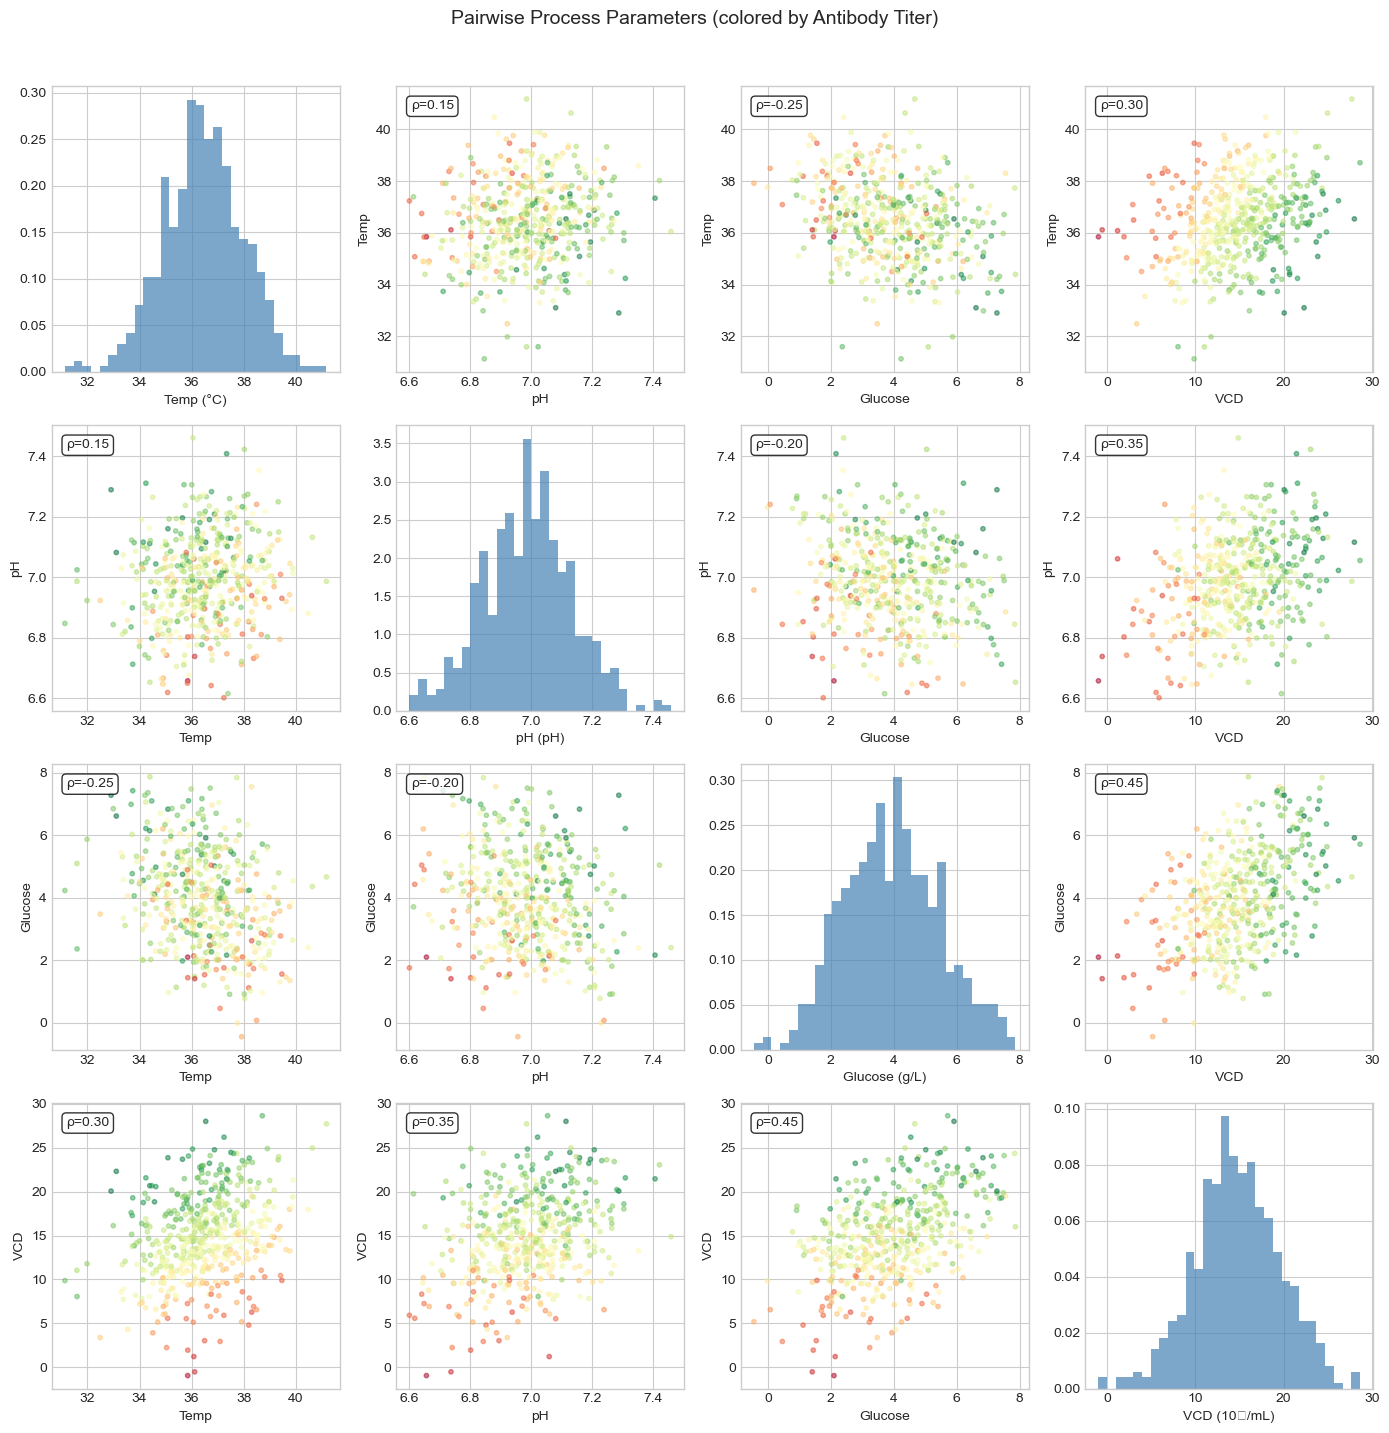

In [21]:
# Visualize pairwise relationships
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

# Plot all pairs (excluding diagonal)
for i in range(4):  # First 4 variables (process parameters)
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram of the variable
            ax.hist(data[:, i], bins=30, density=True, alpha=0.7, color='steelblue')
            ax.set_xlabel(f"{variable_names[i]} {variable_units[i]}")
        else:
            # Off-diagonal: scatter plot colored by titer
            scatter = ax.scatter(data[:, j], data[:, i], c=data[:, TITER], 
                               cmap='RdYlGn', alpha=0.5, s=10)
            ax.set_xlabel(f"{variable_names[j]}")
            ax.set_ylabel(f"{variable_names[i]}")
            # Add correlation in corner
            ax.text(0.05, 0.95, f"ρ={R[i,j]:.2f}", transform=ax.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Pairwise Process Parameters (colored by Antibody Titer)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

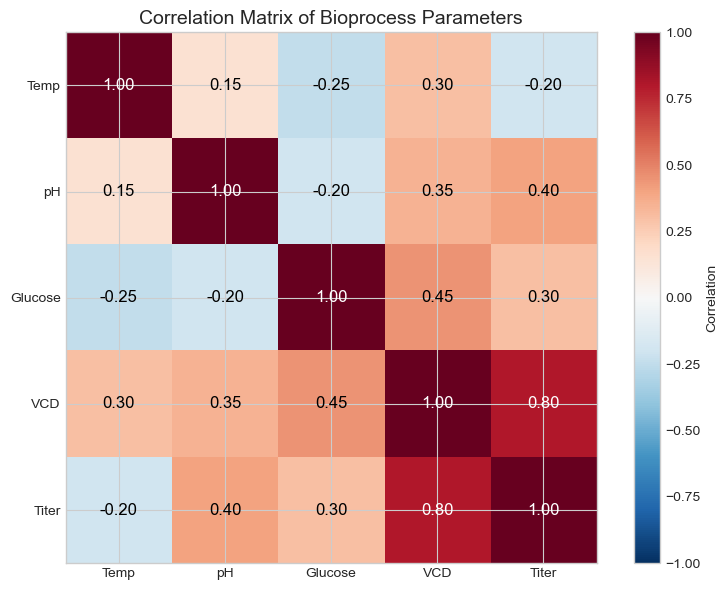

In [22]:
# Show correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)

# Add text annotations
for i in range(5):
    for j in range(5):
        color = 'white' if abs(R[i,j]) > 0.5 else 'black'
        ax.text(j, i, f"{R[i,j]:.2f}", ha='center', va='center', color=color, fontsize=12)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(variable_names)
ax.set_yticklabels(variable_names)
plt.colorbar(im, label='Correlation')
plt.title('Correlation Matrix of Bioprocess Parameters', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Implement General Marginal and Conditional Functions

Now we implement the formulas for **arbitrary partitions** of the variables.

In [23]:
def get_marginal(mu, Sigma, indices):
    """
    Get marginal distribution for variables at given indices.
    
    From Eq. 3.27:
    p(y_1) = N(y_1 | μ_1, Σ_11)
    
    Parameters:
    -----------
    mu : array (d,), mean vector
    Sigma : array (d, d), covariance matrix
    indices : list of int, indices of variables for marginal
    
    Returns:
    --------
    mu_marginal : array, marginal mean
    Sigma_marginal : array, marginal covariance
    """
    idx = np.array(indices)
    mu_marginal = mu[idx]
    Sigma_marginal = Sigma[np.ix_(idx, idx)]
    return mu_marginal, Sigma_marginal


def get_conditional(mu, Sigma, y2_values, idx_1, idx_2):
    """
    Get conditional distribution p(y_1 | y_2 = y2_values).
    
    From Eq. 3.28:
    μ_{1|2} = μ_1 + Σ_12 * Σ_22^{-1} * (y_2 - μ_2)
    Σ_{1|2} = Σ_11 - Σ_12 * Σ_22^{-1} * Σ_21
    
    Parameters:
    -----------
    mu : array (d,), mean vector
    Sigma : array (d, d), covariance matrix
    y2_values : array, observed values for variables in idx_2
    idx_1 : list of int, indices of variables to predict
    idx_2 : list of int, indices of observed variables
    
    Returns:
    --------
    mu_cond : array, conditional mean
    Sigma_cond : array, conditional covariance
    """
    idx_1 = np.array(idx_1)
    idx_2 = np.array(idx_2)
    y2_values = np.atleast_1d(y2_values)
    
    # Extract the relevant blocks from μ and Σ
    mu_1 = mu[idx_1]
    mu_2 = mu[idx_2]
    
    Sigma_11 = Sigma[np.ix_(idx_1, idx_1)]
    Sigma_12 = Sigma[np.ix_(idx_1, idx_2)]
    Sigma_21 = Sigma[np.ix_(idx_2, idx_1)]
    Sigma_22 = Sigma[np.ix_(idx_2, idx_2)]
    
    # Compute Σ_22^{-1}
    Sigma_22_inv = np.linalg.inv(Sigma_22)
    
    # Conditional mean: μ_1 + Σ_12 * Σ_22^{-1} * (y_2 - μ_2)
    mu_cond = mu_1 + Sigma_12 @ Sigma_22_inv @ (y2_values - mu_2)
    
    # Conditional covariance: Σ_11 - Σ_12 * Σ_22^{-1} * Σ_21
    Sigma_cond = Sigma_11 - Sigma_12 @ Sigma_22_inv @ Sigma_21
    
    return mu_cond, Sigma_cond

## Step 4: Example 1 - Predict Titer Given ONE Feature (VCD)

This reduces to the 2D case: conditioning on a scalar. Viable cell density is the strongest predictor of antibody titer — more cells produce more antibody.

In [24]:
# Observed: bioreactor run with VCD = 20 × 10^6 cells/mL
observed_vcd = 20.0  # in 10^6 cells/mL

# Predict titer given only VCD
mu_titer_1, Sigma_titer_1 = get_conditional(
    mu, Sigma,
    y2_values=[observed_vcd],
    idx_1=[TITER],     # predict titer
    idx_2=[VCD]        # given VCD
)

sigma_titer_1 = np.sqrt(Sigma_titer_1[0, 0])

print("=" * 65)
print("TITER PREDICTION: Given ONLY Viable Cell Density")
print("=" * 65)
print(f"\nObserved: VCD = {observed_vcd:.0f} × 10⁶ cells/mL")
print(f"\nConditional p(Titer | VCD = {observed_vcd:.0f}):")
print(f"  Expected Titer: {mu_titer_1[0]:.2f} g/L")
print(f"  Std Deviation:  {sigma_titer_1:.2f} g/L")
print(f"\n95% Confidence Interval:")
ci_low = mu_titer_1[0] - 1.96 * sigma_titer_1
ci_high = mu_titer_1[0] + 1.96 * sigma_titer_1
print(f"  {ci_low:.2f} to {ci_high:.2f} g/L")

# Compare to marginal
mu_titer_marginal, Sigma_titer_marginal = get_marginal(mu, Sigma, [TITER])
variance_reduction = 1 - Sigma_titer_1[0,0] / Sigma_titer_marginal[0,0]
print(f"\nVariance reduction from knowing VCD: {variance_reduction*100:.1f}%")

TITER PREDICTION: Given ONLY Viable Cell Density

Observed: VCD = 20 × 10⁶ cells/mL

Conditional p(Titer | VCD = 20):
  Expected Titer: 4.46 g/L
  Std Deviation:  0.72 g/L

95% Confidence Interval:
  3.05 to 5.87 g/L

Variance reduction from knowing VCD: 64.0%


## Step 5: Example 2 - Predict Titer Given TWO Features (VCD + Glucose)

Now we condition on a **2D vector**. The formula is the same, but $\boldsymbol{\Sigma}_{22}$ is now 2×2. Adding glucose information tells us about nutrient availability.

In [25]:
# Observed: VCD = 20 × 10^6 cells/mL with glucose = 5.0 g/L
observed_vcd = 20.0
observed_gluc = 5.0

# Predict titer given VCD AND glucose
mu_titer_2, Sigma_titer_2 = get_conditional(
    mu, Sigma,
    y2_values=[observed_gluc, observed_vcd],
    idx_1=[TITER],         # predict titer
    idx_2=[GLUC, VCD]      # given glucose and VCD
)

sigma_titer_2 = np.sqrt(Sigma_titer_2[0, 0])

print("=" * 65)
print("TITER PREDICTION: Given VCD AND Glucose")
print("=" * 65)
print(f"\nObserved: VCD = {observed_vcd:.0f} × 10⁶ cells/mL, Glucose = {observed_gluc:.1f} g/L")
print(f"\nConditional p(Titer | VCD, Glucose):")
print(f"  Expected Titer: {mu_titer_2[0]:.2f} g/L")
print(f"  Std Deviation:  {sigma_titer_2:.2f} g/L")
print(f"\n95% Confidence Interval:")
ci_low = mu_titer_2[0] - 1.96 * sigma_titer_2
ci_high = mu_titer_2[0] + 1.96 * sigma_titer_2
print(f"  {ci_low:.2f} to {ci_high:.2f} g/L")

variance_reduction = 1 - Sigma_titer_2[0,0] / Sigma_titer_marginal[0,0]
print(f"\nVariance reduction from knowing VCD + Glucose: {variance_reduction*100:.1f}%")

TITER PREDICTION: Given VCD AND Glucose

Observed: VCD = 20 × 10⁶ cells/mL, Glucose = 5.0 g/L

Conditional p(Titer | VCD, Glucose):
  Expected Titer: 4.44 g/L
  Std Deviation:  0.72 g/L

95% Confidence Interval:
  3.04 to 5.84 g/L

Variance reduction from knowing VCD + Glucose: 64.5%


## Step 6: Example 3 - Predict Titer Given ALL Four Process Parameters

This is the most informative case: conditioning on a **4D vector**. A process engineer has measured all parameters and wants the best possible titer prediction.

In [26]:
# Observed: Complete bioreactor profile
observed_temp = 35.0   # 35°C (slightly below average — production phase shift)
observed_ph = 7.1      # pH 7.1
observed_gluc = 5.0    # 5.0 g/L glucose
observed_vcd = 20.0    # 20 × 10^6 cells/mL

# Predict titer given ALL parameters
mu_titer_4, Sigma_titer_4 = get_conditional(
    mu, Sigma,
    y2_values=[observed_temp, observed_ph, observed_gluc, observed_vcd],
    idx_1=[TITER],
    idx_2=[TEMP, PH, GLUC, VCD]
)

sigma_titer_4 = np.sqrt(Sigma_titer_4[0, 0])

print("=" * 65)
print("TITER PREDICTION: Given ALL Process Parameters")
print("=" * 65)
print(f"\nObserved Bioreactor Profile:")
print(f"  Temperature:    {observed_temp:.1f} °C")
print(f"  pH:             {observed_ph:.2f}")
print(f"  Glucose:        {observed_gluc:.1f} g/L")
print(f"  VCD:            {observed_vcd:.0f} × 10⁶ cells/mL")
print(f"\nConditional p(Titer | Temp, pH, Glucose, VCD):")
print(f"  Expected Titer: {mu_titer_4[0]:.2f} g/L")
print(f"  Std Deviation:  {sigma_titer_4:.2f} g/L")
print(f"\n95% Confidence Interval:")
ci_low = mu_titer_4[0] - 1.96 * sigma_titer_4
ci_high = mu_titer_4[0] + 1.96 * sigma_titer_4
print(f"  {ci_low:.2f} to {ci_high:.2f} g/L")

variance_reduction = 1 - Sigma_titer_4[0,0] / Sigma_titer_marginal[0,0]
print(f"\nVariance reduction from knowing ALL parameters: {variance_reduction*100:.1f}%")

TITER PREDICTION: Given ALL Process Parameters

Observed Bioreactor Profile:
  Temperature:    35.0 °C
  pH:             7.10
  Glucose:        5.0 g/L
  VCD:            20 × 10⁶ cells/mL

Conditional p(Titer | Temp, pH, Glucose, VCD):
  Expected Titer: 5.37 g/L
  Std Deviation:  0.27 g/L

95% Confidence Interval:
  4.84 to 5.91 g/L

Variance reduction from knowing ALL parameters: 94.8%


## Step 7: Comparing Predictions with Different Information

Let's visualize how adding more process measurements reduces uncertainty in our titer prediction.

In [27]:
# Compare all predictions
print("=" * 75)
print("COMPARISON: How Information Reduces Uncertainty")
print("=" * 75)
print(f"\nBioreactor: {observed_temp}°C, pH {observed_ph}, "
      f"{observed_gluc} g/L glucose, VCD {observed_vcd} × 10⁶/mL")
print("\n" + "-" * 75)
print(f"{'Conditioning On':<30} {'E[Titer]':>12} {'Std Dev':>12} {'Var Reduction':>15}")
print("-" * 75)

results = [
    ("Nothing (marginal)", mu_titer_marginal[0], np.sqrt(Sigma_titer_marginal[0,0]), 0),
    ("VCD only", mu_titer_1[0], sigma_titer_1, 
     1 - Sigma_titer_1[0,0]/Sigma_titer_marginal[0,0]),
    ("VCD + Glucose", mu_titer_2[0], sigma_titer_2,
     1 - Sigma_titer_2[0,0]/Sigma_titer_marginal[0,0]),
    ("All 4 parameters", mu_titer_4[0], sigma_titer_4,
     1 - Sigma_titer_4[0,0]/Sigma_titer_marginal[0,0]),
]

for name, mean, std, var_red in results:
    print(f"{name:<30} {mean:>11.2f} g/L {std:>10.2f} g/L {var_red*100:>14.1f}%")

COMPARISON: How Information Reduces Uncertainty

Bioreactor: 35.0°C, pH 7.1, 5.0 g/L glucose, VCD 20.0 × 10⁶/mL

---------------------------------------------------------------------------
Conditioning On                    E[Titer]      Std Dev   Var Reduction
---------------------------------------------------------------------------
Nothing (marginal)                    3.50 g/L       1.20 g/L            0.0%
VCD only                              4.46 g/L       0.72 g/L           64.0%
VCD + Glucose                         4.44 g/L       0.72 g/L           64.5%
All 4 parameters                      5.37 g/L       0.27 g/L           94.8%


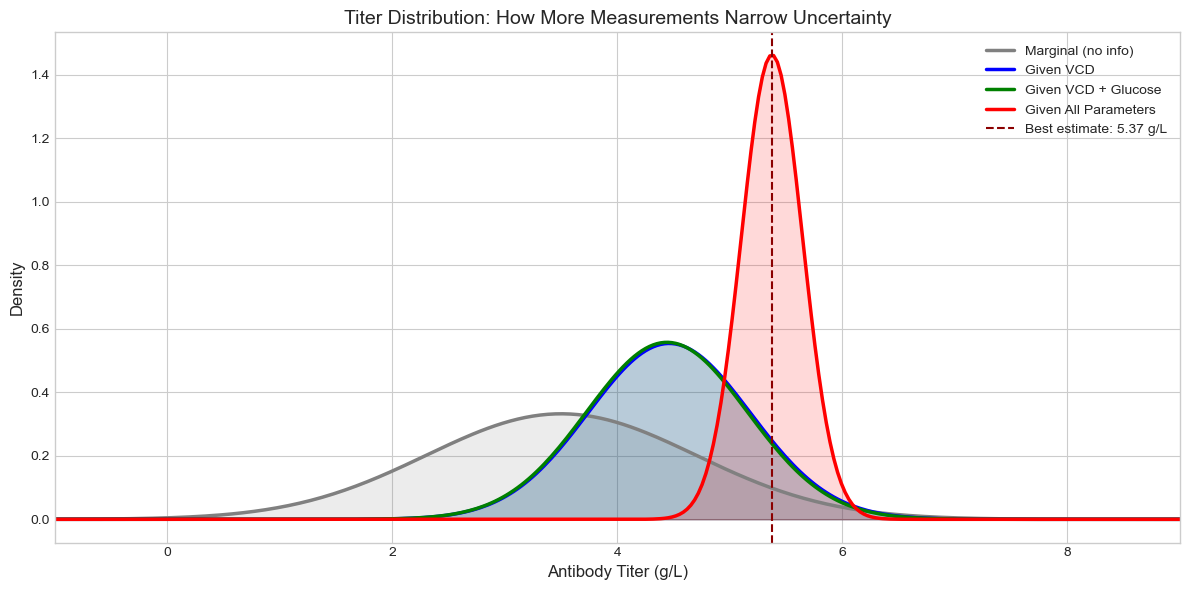

In [28]:
# Visualize the distributions
fig, ax = plt.subplots(figsize=(12, 6))

titer_range = np.linspace(-1, 9, 300)
colors = ['gray', 'blue', 'green', 'red']
labels = ['Marginal (no info)', 'Given VCD', 'Given VCD + Glucose', 'Given All Parameters']

for (name, mean, std, _), color, label in zip(results, colors, labels):
    pdf = stats.norm.pdf(titer_range, mean, std)
    ax.plot(titer_range, pdf, color=color, linewidth=2.5, label=label)
    ax.fill_between(titer_range, pdf, alpha=0.15, color=color)

ax.axvline(x=mu_titer_4[0], color='darkred', linestyle='--', linewidth=1.5,
           label=f'Best estimate: {mu_titer_4[0]:.2f} g/L')

ax.set_xlabel('Antibody Titer (g/L)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Titer Distribution: How More Measurements Narrow Uncertainty', fontsize=14)
ax.legend(loc='upper right')
ax.set_xlim(-1, 9)
plt.tight_layout()
plt.show()

## Step 8: Predicting MULTIPLE Variables at Once

The formulas also let us predict **multiple variables simultaneously**. 

Example: Given only the culture temperature, predict **both** VCD and titer jointly, including their residual correlation. This is useful when temperature is set early in a run and we want to forecast both cell growth and productivity.

In [29]:
# Given: culture temperature is 34°C (a mild hypothermic shift)
observed_temp_joint = 34.0

# Predict VCD AND titer jointly given temperature
mu_joint, Sigma_joint = get_conditional(
    mu, Sigma,
    y2_values=[observed_temp_joint],
    idx_1=[VCD, TITER],  # predict BOTH
    idx_2=[TEMP]          # given temperature
)

print("=" * 65)
print("JOINT PREDICTION: VCD AND Titer Given Temperature")
print("=" * 65)
print(f"\nObserved: Culture temperature = {observed_temp_joint:.0f}°C")
print(f"\nConditional p(VCD, Titer | Temp = {observed_temp_joint:.0f}°C):")
print(f"\n  Conditional Mean Vector:")
print(f"    E[VCD | Temp]:   {mu_joint[0]:.1f} × 10⁶ cells/mL")
print(f"    E[Titer | Temp]: {mu_joint[1]:.2f} g/L")
print(f"\n  Conditional Covariance Matrix:")
print(f"    Σ_cond = ")
print(f"    [{Sigma_joint[0,0]:>8.3f}  {Sigma_joint[0,1]:>8.3f}]  (VCD)")
print(f"    [{Sigma_joint[1,0]:>8.3f}  {Sigma_joint[1,1]:>8.3f}]  (Titer)")

# Extract conditional correlation
cond_corr = Sigma_joint[0,1] / (np.sqrt(Sigma_joint[0,0]) * np.sqrt(Sigma_joint[1,1]))
print(f"\n  Conditional correlation ρ(VCD, Titer | Temp): {cond_corr:.3f}")
print(f"  (Original correlation: {R[VCD, TITER]:.3f})")

JOINT PREDICTION: VCD AND Titer Given Temperature

Observed: Culture temperature = 34°C

Conditional p(VCD, Titer | Temp = 34°C):

  Conditional Mean Vector:
    E[VCD | Temp]:   12.5 × 10⁶ cells/mL
    E[Titer | Temp]: 3.90 g/L

  Conditional Covariance Matrix:
    Σ_cond = 
    [  22.750     5.160]  (VCD)
    [   5.160     1.382]  (Titer)

  Conditional correlation ρ(VCD, Titer | Temp): 0.920
  (Original correlation: 0.800)


/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_85534/3446176991.py:54: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


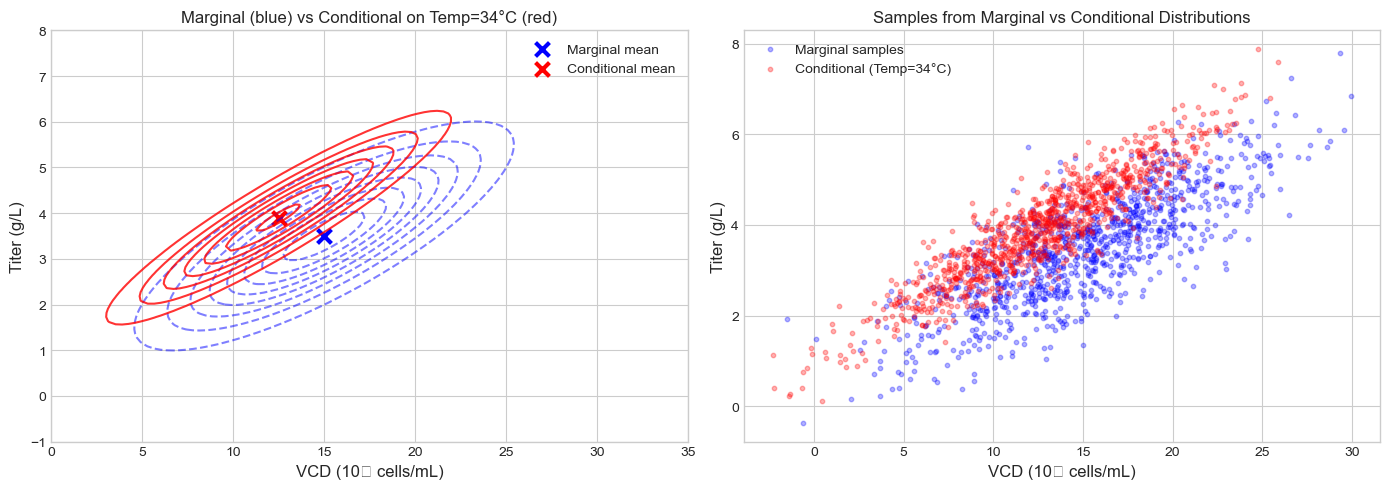

In [30]:
# Visualize the joint conditional distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Original joint vs conditional joint
ax1 = axes[0]

# Get marginal for VCD and titer (original joint)
mu_marg, Sigma_marg = get_marginal(mu, Sigma, [VCD, TITER])

# Create grids
vcd_grid = np.linspace(0, 35, 100)
titer_grid = np.linspace(-1, 8, 100)
X, Y = np.meshgrid(vcd_grid, titer_grid)
pos = np.dstack((X, Y))

# Marginal contours
rv_marg = multivariate_normal(mu_marg, Sigma_marg)
Z_marg = rv_marg.pdf(pos)
ax1.contour(X, Y, Z_marg, levels=8, colors='blue', alpha=0.5, linestyles='--')

# Conditional contours
rv_cond = multivariate_normal(mu_joint, Sigma_joint)
Z_cond = rv_cond.pdf(pos)
ax1.contour(X, Y, Z_cond, levels=8, colors='red', alpha=0.8)

# Mark means
ax1.scatter([mu_marg[0]], [mu_marg[1]], color='blue', s=100, 
            marker='x', linewidths=3, label='Marginal mean')
ax1.scatter([mu_joint[0]], [mu_joint[1]], color='red', s=100,
            marker='x', linewidths=3, label='Conditional mean')

ax1.set_xlabel('VCD (10⁶ cells/mL)', fontsize=12)
ax1.set_ylabel('Titer (g/L)', fontsize=12)
ax1.set_title(f'Marginal (blue) vs Conditional on Temp={observed_temp_joint:.0f}°C (red)', fontsize=12)
ax1.legend()

# Right: Show how conditioning shifts the distribution
ax2 = axes[1]

# Sample from both distributions
samples_marg = np.random.multivariate_normal(mu_marg, Sigma_marg, 1000)
samples_cond = np.random.multivariate_normal(mu_joint, Sigma_joint, 1000)

ax2.scatter(samples_marg[:, 0], samples_marg[:, 1], 
           alpha=0.3, s=10, color='blue', label='Marginal samples')
ax2.scatter(samples_cond[:, 0], samples_cond[:, 1],
           alpha=0.3, s=10, color='red', label=f'Conditional (Temp={observed_temp_joint:.0f}°C)')

ax2.set_xlabel('VCD (10⁶ cells/mL)', fontsize=12)
ax2.set_ylabel('Titer (g/L)', fontsize=12)
ax2.set_title('Samples from Marginal vs Conditional Distributions', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

## Step 9: Detailed Look at the Matrix Operations

Let's walk through the formulas step by step for a concrete example.

In [31]:
# Example: Predict Titer given VCD and Glucose
# idx_1 = [TITER] = [4]
# idx_2 = [GLUC, VCD] = [2, 3]

idx_1 = [TITER]
idx_2 = [GLUC, VCD]
y2_observed = np.array([5.0, 20.0])  # 5.0 g/L glucose, 20 × 10^6 cells/mL

print("="*70)
print("STEP-BY-STEP: Computing p(Titer | Glucose=5.0, VCD=20)")
print("="*70)

# Step 1: Extract mean components
mu_1 = mu[idx_1]
mu_2 = mu[np.array(idx_2)]
print(f"\n1. Extract mean components:")
print(f"   μ_1 (Titer) = {mu_1}")
print(f"   μ_2 (Glucose, VCD) = {mu_2}")

# Step 2: Extract covariance blocks
Sigma_11 = Sigma[np.ix_(idx_1, idx_1)]
Sigma_12 = Sigma[np.ix_(idx_1, idx_2)]
Sigma_21 = Sigma[np.ix_(idx_2, idx_1)]
Sigma_22 = Sigma[np.ix_(idx_2, idx_2)]

print(f"\n2. Extract covariance blocks:")
print(f"   Σ_11 (Titer, Titer) = {Sigma_11}  [1×1 matrix]")
print(f"   Σ_12 (Titer, [Gluc,VCD]) = {Sigma_12}  [1×2 matrix]")
print(f"   Σ_21 ([Gluc,VCD], Titer) = \n{Sigma_21}  [2×1 matrix]")
print(f"   Σ_22 ([Gluc,VCD], [Gluc,VCD]) = \n{Sigma_22}  [2×2 matrix]")

# Step 3: Compute Σ_22 inverse
Sigma_22_inv = np.linalg.inv(Sigma_22)
print(f"\n3. Compute Σ_22^(-1):")
print(f"   Σ_22^(-1) = \n{Sigma_22_inv}")

# Step 4: Compute (y_2 - μ_2)
diff = y2_observed - mu_2
print(f"\n4. Compute (y_2 - μ_2):")
print(f"   y_2 - μ_2 = {y2_observed} - {mu_2} = {diff}")

# Step 5: Compute conditional mean
adjustment = Sigma_12 @ Sigma_22_inv @ diff
mu_cond = mu_1 + adjustment
print(f"\n5. Compute conditional mean:")
print(f"   Σ_12 @ Σ_22^(-1) @ (y_2 - μ_2) = {adjustment}")
print(f"   μ_{{1|2}} = μ_1 + adjustment = {mu_1} + {adjustment} = {mu_cond}")
print(f"   → Expected Titer = {mu_cond[0]:.2f} g/L")

# Step 6: Compute conditional covariance
Sigma_cond = Sigma_11 - Sigma_12 @ Sigma_22_inv @ Sigma_21
print(f"\n6. Compute conditional covariance:")
print(f"   Σ_12 @ Σ_22^(-1) @ Σ_21 = {Sigma_12 @ Sigma_22_inv @ Sigma_21}")
print(f"   Σ_{{1|2}} = Σ_11 - (above) = {Sigma_11} - {Sigma_12 @ Sigma_22_inv @ Sigma_21} = {Sigma_cond}")
print(f"   → Conditional Std Dev = {np.sqrt(Sigma_cond[0,0]):.2f} g/L")

STEP-BY-STEP: Computing p(Titer | Glucose=5.0, VCD=20)

1. Extract mean components:
   μ_1 (Titer) = [3.5]
   μ_2 (Glucose, VCD) = [ 4. 15.]

2. Extract covariance blocks:
   Σ_11 (Titer, Titer) = [[1.44]]  [1×1 matrix]
   Σ_12 (Titer, [Gluc,VCD]) = [[0.54 4.8 ]]  [1×2 matrix]
   Σ_21 ([Gluc,VCD], Titer) = 
[[0.54]
 [4.8 ]]  [2×1 matrix]
   Σ_22 ([Gluc,VCD], [Gluc,VCD]) = 
[[ 2.25   3.375]
 [ 3.375 25.   ]]  [2×2 matrix]

3. Compute Σ_22^(-1):
   Σ_22^(-1) = 
[[ 0.55729711 -0.07523511]
 [-0.07523511  0.05015674]]

4. Compute (y_2 - μ_2):
   y_2 - μ_2 = [ 5. 20.] - [ 4. 15.] = [1. 5.]

5. Compute conditional mean:
   Σ_12 @ Σ_22^(-1) @ (y_2 - μ_2) = [0.94043887]
   μ_{1|2} = μ_1 + adjustment = [3.5] + [0.94043887] = [4.44043887]
   → Expected Titer = 4.44 g/L

6. Compute conditional covariance:
   Σ_12 @ Σ_22^(-1) @ Σ_21 = [[0.92810031]]
   Σ_{1|2} = Σ_11 - (above) = [[1.44]] - [[0.92810031]] = [[0.51189969]]
   → Conditional Std Dev = 0.72 g/L


## Step 10: Incremental Information Gain Analysis

Let's see how much each additional feature contributes to reducing uncertainty.

In [32]:
# Test with a specific bioreactor run
run = {
    TEMP: 35.0,    # 35°C
    PH: 7.1,       # pH 7.1
    GLUC: 5.0,     # 5.0 g/L glucose
    VCD: 20.0      # 20 × 10^6 cells/mL
}

# Define feature addition sequences
sequences = [
    ([], "No information (marginal)"),
    ([VCD], "+ Viable Cell Density"),
    ([VCD, GLUC], "+ Glucose"),
    ([VCD, GLUC, PH], "+ pH"),
    ([VCD, GLUC, PH, TEMP], "+ Temperature"),
]

print("="*75)
print("INCREMENTAL INFORMATION GAIN")
print("="*75)
print(f"\nBioreactor: 35°C, pH 7.1, 5.0 g/L glucose, VCD 20 × 10⁶/mL")
print("\n" + "-"*75)
print(f"{'Parameters Known':<35} {'E[Titer]':>10} {'Std':>10} {'Var Red':>10} {'Δ Var Red':>10}")
print("-"*75)

prev_var_red = 0
marginal_var = Sigma[TITER, TITER]

for features, name in sequences:
    if len(features) == 0:
        mean = mu[TITER]
        var = marginal_var
    else:
        y2_values = [run[f] for f in features]
        mu_cond, Sigma_cond = get_conditional(mu, Sigma, y2_values, [TITER], features)
        mean = mu_cond[0]
        var = Sigma_cond[0, 0]
    
    std = np.sqrt(var)
    var_red = 1 - var / marginal_var
    delta_var_red = var_red - prev_var_red
    
    print(f"{name:<35} {mean:>9.2f} g/L {std:>8.2f} g/L {var_red*100:>9.1f}% {delta_var_red*100:>+9.1f}%")
    prev_var_red = var_red

INCREMENTAL INFORMATION GAIN

Bioreactor: 35°C, pH 7.1, 5.0 g/L glucose, VCD 20 × 10⁶/mL

---------------------------------------------------------------------------
Parameters Known                      E[Titer]        Std    Var Red  Δ Var Red
---------------------------------------------------------------------------
No information (marginal)                3.50 g/L     1.20 g/L       0.0%      +0.0%
+ Viable Cell Density                    4.46 g/L     0.72 g/L      64.0%     +64.0%
+ Glucose                                4.44 g/L     0.72 g/L      64.5%      +0.5%
+ pH                                     4.50 g/L     0.70 g/L      65.7%      +1.2%
+ Temperature                            5.37 g/L     0.27 g/L      94.8%     +29.2%


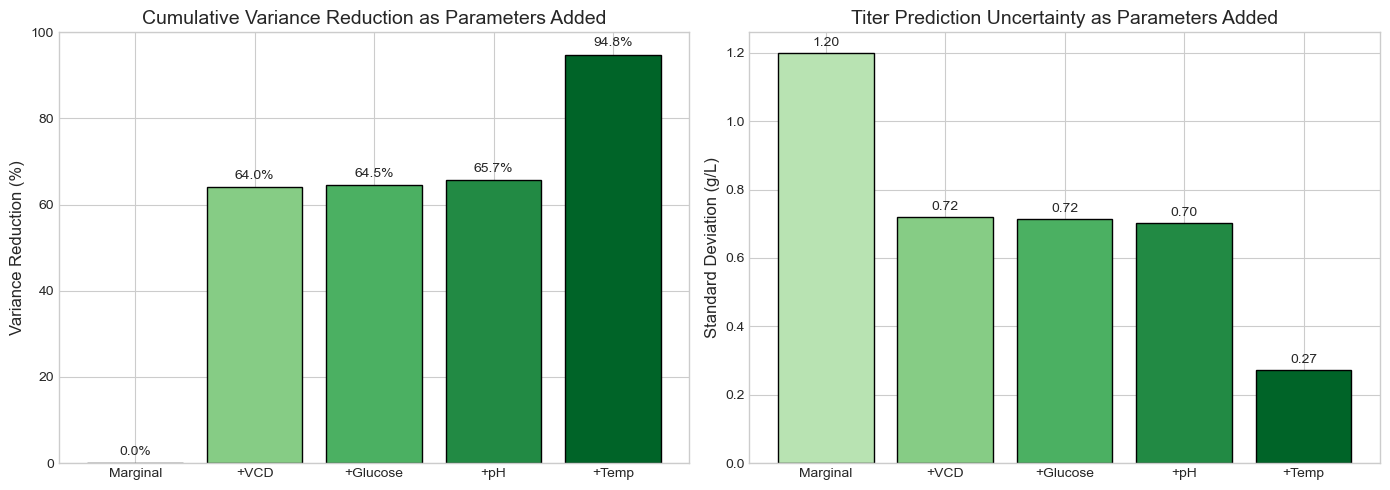

In [33]:
# Visualize the incremental reduction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of variance reduction
ax1 = axes[0]
feature_labels = ['Marginal', '+VCD', '+Glucose', '+pH', '+Temp']
var_reductions = []
stds = []

marginal_var = Sigma[TITER, TITER]
for features, _ in sequences:
    if len(features) == 0:
        var = marginal_var
    else:
        y2_values = [run[f] for f in features]
        _, Sigma_cond = get_conditional(mu, Sigma, y2_values, [TITER], features)
        var = Sigma_cond[0, 0]
    var_reductions.append((1 - var/marginal_var) * 100)
    stds.append(np.sqrt(var))

colors = plt.cm.Greens(np.linspace(0.3, 0.9, 5))
bars = ax1.bar(feature_labels, var_reductions, color=colors, edgecolor='black')
ax1.set_ylabel('Variance Reduction (%)', fontsize=12)
ax1.set_title('Cumulative Variance Reduction as Parameters Added', fontsize=14)
ax1.set_ylim(0, 100)

# Add value labels
for bar, val in zip(bars, var_reductions):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f}%', ha='center', fontsize=10)

# Right: Std deviation reduction
ax2 = axes[1]
bars2 = ax2.bar(feature_labels, stds, color=colors, edgecolor='black')
ax2.set_ylabel('Standard Deviation (g/L)', fontsize=12)
ax2.set_title('Titer Prediction Uncertainty as Parameters Added', fontsize=14)

# Add value labels
for bar, val in zip(bars2, stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 11: The Order Doesn't Matter (for Final Result)

An important property: the **final conditional distribution** is the same regardless of which order we add the conditioning variables.

In [34]:
# Condition on all 4 parameters in different orders
orders = [
    ([VCD, GLUC, PH, TEMP], "VCD → Gluc → pH → Temp"),
    ([TEMP, PH, GLUC, VCD], "Temp → pH → Gluc → VCD"),
    ([GLUC, TEMP, VCD, PH], "Gluc → Temp → VCD → pH"),
    ([PH, VCD, TEMP, GLUC], "pH → VCD → Temp → Gluc"),
]

print("="*65)
print("VERIFICATION: Order of Conditioning Doesn't Matter")
print("="*65)
print(f"\nBioreactor: 35°C, pH 7.1, 5.0 g/L glucose, VCD 20 × 10⁶/mL")
print("\n" + "-"*65)
print(f"{'Conditioning Order':<30} {'E[Titer]':>15} {'Std Dev':>15}")
print("-"*65)

for features, name in orders:
    y2_values = [run[f] for f in features]
    mu_cond, Sigma_cond = get_conditional(mu, Sigma, y2_values, [TITER], features)
    print(f"{name:<30} {mu_cond[0]:>14.4f} g/L {np.sqrt(Sigma_cond[0,0]):>13.4f} g/L")

print("\n✓ All orders give the same result!")

VERIFICATION: Order of Conditioning Doesn't Matter

Bioreactor: 35°C, pH 7.1, 5.0 g/L glucose, VCD 20 × 10⁶/mL

-----------------------------------------------------------------
Conditioning Order                    E[Titer]         Std Dev
-----------------------------------------------------------------
VCD → Gluc → pH → Temp                 5.3731 g/L        0.2726 g/L
Temp → pH → Gluc → VCD                 5.3731 g/L        0.2726 g/L
Gluc → Temp → VCD → pH                 5.3731 g/L        0.2726 g/L
pH → VCD → Temp → Gluc                 5.3731 g/L        0.2726 g/L

✓ All orders give the same result!


## Step 12: Antibody Titer Prediction Tool (5D)

In [35]:
def estimate_titer(temp=None, ph=None, glucose=None, vcd=None):
    """
    Estimate antibody titer given any combination of process parameters.
    Returns the conditional distribution parameters.
    
    Parameters (all optional, in real units):
    - temp: culture temperature (°C)
    - ph: medium pH
    - glucose: glucose concentration (g/L)
    - vcd: viable cell density (10^6 cells/mL)
    """
    # Collect observed parameters
    observed_idx = []
    observed_values = []
    observed_names = []
    
    if temp is not None:
        observed_idx.append(TEMP)
        observed_values.append(temp)
        observed_names.append(f"Temp={temp}°C")
    if ph is not None:
        observed_idx.append(PH)
        observed_values.append(ph)
        observed_names.append(f"pH={ph}")
    if glucose is not None:
        observed_idx.append(GLUC)
        observed_values.append(glucose)
        observed_names.append(f"Glucose={glucose} g/L")
    if vcd is not None:
        observed_idx.append(VCD)
        observed_values.append(vcd)
        observed_names.append(f"VCD={vcd}")
    
    if len(observed_idx) == 0:
        # No observations - return marginal
        mean = mu[TITER]
        std = np.sqrt(Sigma[TITER, TITER])
        var_red = 0
    else:
        mu_cond, Sigma_cond = get_conditional(
            mu, Sigma, observed_values, [TITER], observed_idx
        )
        mean = mu_cond[0]
        std = np.sqrt(Sigma_cond[0, 0])
        var_red = 1 - Sigma_cond[0, 0] / Sigma[TITER, TITER]
    
    return {
        'expected_titer': mean,
        'std': std,
        'ci_95': (mean - 1.96*std, mean + 1.96*std),
        'variance_reduction': var_red,
        'observed': ', '.join(observed_names) if observed_names else 'None'
    }


# Demo the tool
print("="*70)
print("mAb TITER PREDICTION TOOL (5D Gaussian Model)")
print("="*70)

test_cases = [
    {},  # No info
    {'vcd': 20},
    {'vcd': 20, 'glucose': 5.0},
    {'vcd': 20, 'glucose': 5.0, 'ph': 7.1},
    {'vcd': 20, 'glucose': 5.0, 'ph': 7.1, 'temp': 35.0},
    {'temp': 33.0, 'ph': 6.9, 'glucose': 2.0, 'vcd': 8.0},    # Stressed, low-density culture
    {'temp': 34.0, 'ph': 7.1, 'glucose': 6.0, 'vcd': 25.0},    # Optimal high-density run
]

for kwargs in test_cases:
    result = estimate_titer(**kwargs)
    print(f"\nGiven: {result['observed']}")
    print(f"  Expected Titer: {result['expected_titer']:.2f} g/L")
    print(f"  95% CI: {result['ci_95'][0]:.2f} - {result['ci_95'][1]:.2f} g/L")
    print(f"  Variance Reduction: {result['variance_reduction']*100:.1f}%")

mAb TITER PREDICTION TOOL (5D Gaussian Model)

Given: None
  Expected Titer: 3.50 g/L
  95% CI: 1.15 - 5.85 g/L
  Variance Reduction: 0.0%

Given: VCD=20
  Expected Titer: 4.46 g/L
  95% CI: 3.05 - 5.87 g/L
  Variance Reduction: 64.0%

Given: Glucose=5.0 g/L, VCD=20
  Expected Titer: 4.44 g/L
  95% CI: 3.04 - 5.84 g/L
  Variance Reduction: 64.5%

Given: pH=7.1, Glucose=5.0 g/L, VCD=20
  Expected Titer: 4.50 g/L
  95% CI: 3.13 - 5.88 g/L
  Variance Reduction: 65.7%

Given: Temp=35.0°C, pH=7.1, Glucose=5.0 g/L, VCD=20
  Expected Titer: 5.37 g/L
  95% CI: 4.84 - 5.91 g/L
  Variance Reduction: 94.8%

Given: Temp=33.0°C, pH=6.9, Glucose=2.0 g/L, VCD=8.0
  Expected Titer: 3.95 g/L
  95% CI: 3.42 - 4.49 g/L
  Variance Reduction: 94.8%

Given: Temp=34.0°C, pH=7.1, Glucose=6.0 g/L, VCD=25.0
  Expected Titer: 6.98 g/L
  95% CI: 6.44 - 7.51 g/L
  Variance Reduction: 94.8%


## Summary

### Key Takeaways from the 5D Case:

1. **The formulas are the same** as in 2D, but with matrices:
   - $\boldsymbol{\mu}_{1|2} = \boldsymbol{\mu}_1 + \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} (\mathbf{y}_2 - \boldsymbol{\mu}_2)$
   - $\boldsymbol{\Sigma}_{1|2} = \boldsymbol{\Sigma}_{11} - \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} \boldsymbol{\Sigma}_{21}$

2. **Dimensions of the blocks**:
   - If predicting $d_1$ variables from $d_2$ observations:
   - $\boldsymbol{\Sigma}_{11}$ is $d_1 \times d_1$
   - $\boldsymbol{\Sigma}_{12}$ is $d_1 \times d_2$
   - $\boldsymbol{\Sigma}_{22}^{-1}$ requires inverting a $d_2 \times d_2$ matrix

3. **More parameters = less uncertainty**:
   - Each additional correlated measurement reduces prediction variance
   - But diminishing returns: adding the 4th parameter helps less than adding the 1st
   - Parameters that are highly correlated with the target help most

4. **Order doesn't matter**:
   - The final conditional distribution is the same regardless of which order you condition on the variables

5. **Bioprocessing insight**:
   - In our 5D CHO cell culture model, viable cell density (VCD) is the single most informative predictor of antibody titer (ρ = 0.80)
   - VCD alone provides ~64% of the variance reduction — more cells simply produce more antibody
   - Adding temperature and pH further helps because they influence specific productivity (g/cell/day)